## importing libs


In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import lightning as pl
import scipy.sparse as sp
import datasets
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import load_svmlight_file

# Disable Ray before any p2pfl imports — keeps training in-process so
# lm._metrics is populated and accessible after training completes.
from p2pfl.settings import Settings
Settings.general.DISABLE_RAY = True

from p2pfl.learning.dataset.p2pfl_dataset import P2PFLDataset
from p2pfl.learning.frameworks.pytorch.lightning_model import LightningModel
from p2pfl.node import Node
from p2pfl.management.logger import logger

/home/sreekars_wsl/.virtualenvs/svmenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
from config import CONFIG, CODE_DIR

os.chdir(CODE_DIR)

In [ ]:
# ═══════════════════════════════════════════════════════════
# Data Loading
# ═══════════════════════════════════════════════════════════
np.random.seed(CONFIG["SEED"])
torch.manual_seed(CONFIG["SEED"])

# Resolve paths — works whether kernel runs from repo root or src/
_here       = Path("src") if Path("src").exists() else Path(".")
_data_train = _here / "data" / "train" / "rcv1_train.binary"
_data_test  = _here / "data" / "test"  / "rcv1_test.binary"

X_csr, y = load_svmlight_file(str(_data_train))
y = np.sign(y).astype(np.float32)   # ensure strictly ±1

n_train = X_csr.shape[0]
perm    = np.random.permutation(n_train)
X_csr   = X_csr[perm].tocsr()
y       = y[perm]

# ── Split into N_WORKERS partitions ──────────────────────────────────
n_workers = CONFIG["NUM_WORKERS"]
part_idxs = np.array_split(np.arange(n_train), n_workers)

worker_data = []
for local_idxs in part_idxs:
    X_part  = X_csr[local_idxs].tocsr()
    y_part  = y[local_idxs]
    n_local = len(local_idxs)

    # HF dataset stores only local index + label
    # Sparse features stay in scipy — no dense expansion needed
    hf_split = datasets.Dataset.from_dict({
        "idx": list(range(n_local)),
        "y":   y_part.tolist(),
    })
    hf_ds = datasets.DatasetDict({"train": hf_split, "test": hf_split})

    worker_data.append({
        "hf_dataset": hf_ds,
        "X_csr":      X_part,
        "y":          y_part,
        "n_local":    n_local,
    })

for i, d in enumerate(worker_data):
    print(f"Worker {i}: {d['n_local']} samples  "
          f"avg nnz/sample ≈ {d['X_csr'].nnz // d['n_local']}")

In [4]:
# ═══════════════════════════════════════════════════════════
# MODEL — LinearSVM + SDCA LightningModule
# ═══════════════════════════════════════════════════════════

class _Shared:
    """Wrapper that survives deepcopy by returning the same object.
    
    p2pfl calls copy.deepcopy(lm) after each aggregation round.
    SDCA state (alpha, averages, metrics) must persist across those copies,
    so we hold all mutable state in a single _Shared container whose
    __deepcopy__ always returns self.
    """
    __slots__ = ("alpha", "w_avg", "avg_cnt", "step", "metrics", "start")
    def __init__(self, n, d):
        self.alpha   = torch.zeros(n, dtype=torch.float32)
        self.w_avg   = torch.zeros(d, dtype=torch.float32)
        self.avg_cnt = 0
        self.step    = 0
        self.metrics: list = []
        self.start   = time.time()
    def __deepcopy__(self, memo):
        return self   # intentionally shared — all copies see the same state


class LinearSVM(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.weight = nn.Parameter(
            torch.zeros(n_features, dtype=torch.float32),
            requires_grad=False,
        )
    def forward(self, x):
        return x @ self.weight


class SVMSDCALightning(pl.LightningModule):
    def __init__(self, X_csr, y_np, lambda_reg, t0_fraction=0.5, _shared=None):
        super().__init__()
        self.automatic_optimization = False
        n, d = X_csr.shape
        self.n = n; self.d = d
        self.lambda_reg = lambda_reg
        self._t0 = max(1, int(t0_fraction * n))
        self.model = LinearSVM(d)
        self._X_csr = X_csr
        self._y_np  = y_np
        # _shared holds all mutable SDCA state — shared across deepcopy rounds
        self._s = _shared if _shared is not None else _Shared(n, d)

    # ── convenience shorthands ──────────────────────────────────────
    @property
    def _metrics(self): return self._s.metrics

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=0.0)

    def on_fit_start(self):
        self.cpu()

    def on_test_start(self):
        self.cpu()

    def training_step(self, batch, batch_idx):
        s    = self._s
        idxs = batch["idx"].view(-1)
        ys   = batch["y"].view(-1).float()
        w    = self.model.weight.data.cpu()
        loss_sum = 0.0
        for k in range(len(idxs)):
            local_i = int(idxs[k].item()); yi = float(ys[k].item())
            xi_np = self._X_csr[local_i].toarray().ravel().astype(np.float32)
            xi = torch.from_numpy(xi_np)
            xi_norm_sq = float(xi.dot(xi).item())
            if xi_norm_sq < 1e-12: continue
            alpha_i = float(s.alpha[local_i].item())
            score   = float(xi.dot(w).item()) * yi
            denom        = xi_norm_sq / (self.lambda_reg * self.n)
            new_alpha_yi = max(0.0, min(1.0, (1.0 - score) / denom + alpha_i * yi))
            delta        = yi * new_alpha_yi - alpha_i
            s.alpha[local_i] += delta
            w.add_(xi, alpha=delta / (self.lambda_reg * self.n))
            s.step += 1
            if s.step >= self._t0:
                s.w_avg.add_(w); s.avg_cnt += 1
            loss_sum += max(0.0, 1.0 - yi * float(xi.dot(w).item()))
        self.model.weight.data.copy_(w)
        avg_loss = loss_sum / max(1, len(idxs))
        self.log("train_loss", avg_loss, prog_bar=True, on_step=False, on_epoch=True)
        return torch.tensor(avg_loss).detach()

    def validation_step(self, batch, batch_idx):
        return torch.tensor(0.0)

    def test_step(self, batch, batch_idx):
        idxs = batch["idx"].view(-1).cpu().numpy()
        ys   = batch["y"].view(-1).float().cpu().numpy()
        w_np = self.model.weight.data.cpu().numpy()
        X_batch = self._X_csr[idxs].toarray().astype(np.float32)
        scores  = X_batch @ w_np
        hinge   = float(np.mean(np.maximum(0.0, 1.0 - ys * scores)))
        self.log("test_hinge_loss", hinge, on_step=False, on_epoch=True)
        return torch.tensor(hinge).detach()

    def on_train_epoch_end(self):
        self._compute_metrics()

    def _compute_metrics(self):
        s = self._s
        if s.avg_cnt > 0:
            w_np = (s.w_avg / s.avg_cnt).cpu().numpy()
        else:
            w_np = self.model.weight.data.cpu().numpy()
        alpha_np = s.alpha.cpu().numpy()
        scores  = self._X_csr.dot(w_np)
        margins = 1.0 - self._y_np * scores
        hinge   = float(np.mean(np.maximum(0.0, margins)))
        reg     = float((self.lambda_reg / 2.0) * np.dot(w_np, w_np))
        primal  = hinge + reg
        w_alpha   = self._X_csr.T.dot(alpha_np) / (self.lambda_reg * self.n)
        dual_data = float(np.mean(alpha_np * self._y_np))
        dual_reg  = float((self.lambda_reg / 2.0) * np.dot(w_alpha, w_alpha))
        dual      = dual_data - dual_reg
        gap  = primal - dual
        wall = time.time() - s.start
        rnd  = len(s.metrics) + 1
        for name, val in [("primal", primal), ("dual", dual),
                           ("duality_gap", gap), ("hinge_loss", hinge), ("wall_time", wall)]:
            self.log(name, float(val), on_step=False, on_epoch=True)
        s.metrics.append({"round": rnd, "primal": primal, "dual": dual,
                           "duality_gap": gap, "hinge_loss": hinge, "wall_time": wall})
        print(f"[SDCA] round={rnd}  gap={gap:.6f}  "
              f"primal={primal:.6f}  dual={dual:.6f}  "
              f"hinge={hinge:.4f}  t={wall:.1f}s")

In [5]:
# ═══════════════════════════════════════════════════════════
# Topology Builder
# ═══════════════════════════════════════════════════════════

def connect_topology(nodes: list, topology: str, base_port: int):
    """
    Wire nodes together according to the chosen topology.

    topology options:
        "ring"  — each node connects to its immediate successor (default)
        "full"  — every node connects to every other node
        "star"  — nodes 1..N-1 all connect to node 0 only
        "mesh"  — each node connects to neighbours at distance 1 and 2
    """
    n     = len(nodes)
    added = set()

    def _link(i: int, j: int):
        key = (min(i, j), max(i, j))
        if key not in added:
            nodes[i].connect(f"127.0.0.1:{base_port + j}")
            added.add(key)

    if topology == "ring":
        for i in range(n):
            _link(i, (i + 1) % n)

    elif topology == "full":
        for i in range(n):
            for j in range(i + 1, n):
                _link(i, j)

    elif topology == "star":
        for i in range(1, n):
            _link(0, i)

    elif topology == "mesh":
        for i in range(n):
            _link(i, (i + 1) % n)
            _link(i, (i + 2) % n)

    else:
        raise ValueError(
            f"Unknown topology '{topology}'. "
            "Choose from: ring | full | star | mesh"
        )

    print(f"Topology '{topology}' wired — {len(added)} edge(s).")

In [6]:
# ═══════════════════════════════════════════════════════════
# Node Setup and Training
# ═══════════════════════════════════════════════════════════

lightning_modules = []
nodes = []

for i in range(CONFIG["NUM_WORKERS"]):
    d = worker_data[i]

    lm = SVMSDCALightning(
        X_csr       = d["X_csr"],
        y_np        = d["y"],
        lambda_reg  = CONFIG["LAMBDA"],
        t0_fraction = CONFIG["T0_FRACTION"],
    )
    lightning_modules.append(lm)

    node = Node(
        model = LightningModel(lm),
        data  = P2PFLDataset(d["hf_dataset"], dataset_name=f"rcv1_worker_{i}"),
        addr  = f"127.0.0.1:{CONFIG['BASE_PORT'] + i}",
    )
    nodes.append(node)

# ── Start all nodes ────────────────────────────────────────────────
for node in nodes:
    node.start()

# ── Wire topology ──────────────────────────────────────────────────
connect_topology(nodes, CONFIG["TOPOLOGY"], CONFIG["BASE_PORT"])

time.sleep(4)   # allow connections to stabilise

# ── Trigger learning from node 0 only (gossip propagates to all) ──
nodes[0].set_start_learning(
    rounds = CONFIG["ROUNDS"],
    epochs = CONFIG["EPOCHS"],
)

# ── Wait for completion ────────────────────────────────────────────
while True:
    time.sleep(1)
    if nodes[0].state.round is None:
        break

print("Training complete.")

# ── Teardown ───────────────────────────────────────────────────────
for node in nodes:
    node.stop()

[ 2026-04-24 19:27:02 | 127.0.0.1:6000 | INFO ] 🏁 Starting gossiper...


[ 2026-04-24 19:27:02 | 127.0.0.1:6001 | INFO ] 🏁 Starting gossiper...


[ 2026-04-24 19:27:02 | 127.0.0.1:6002 | INFO ] 🏁 Starting gossiper...


[ 2026-04-24 19:27:02 | 127.0.0.1:6003 | INFO ] 🏁 Starting gossiper...


[ 2026-04-24 19:27:02 | 127.0.0.1:6004 | INFO ] 🏁 Starting gossiper...


...

[ 2026-04-24 19:41:32 | 127.0.0.1:6003 | INFO ] Stopping node...


[ 2026-04-24 19:41:32 | 127.0.0.1:6003 | INFO ] 🛑 Stopping gossiper...


[ 2026-04-24 19:41:32 | 127.0.0.1:6004 | INFO ] Stopping node...


[ 2026-04-24 19:41:32 | 127.0.0.1:6004 | INFO ] 🛑 Stopping gossiper...


Training complete.


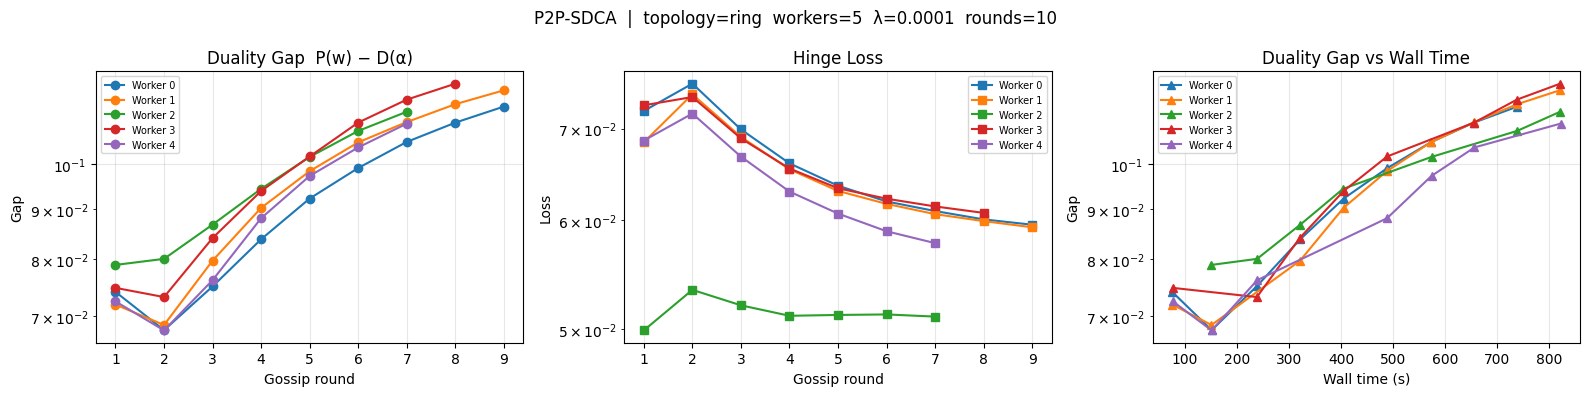


Worker     Final Gap   Final Hinge      Primal        Dual    Time (s)
──────────────────────────────────────────────────────────────────
     0      0.114361      0.059571    0.119480    0.005119       738.6
     1      0.118801      0.059317    0.121933    0.003132       819.7
     2      0.112985      0.051059    0.121337    0.008352       820.7
     3      0.120660      0.060765    0.124312    0.003652       820.5
     4      0.109880      0.057759    0.116881    0.007002       821.3


In [8]:
# ═══════════════════════════════════════════════════════════
# Convergence Metrics
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    f"P2P-SDCA  |  topology={CONFIG['TOPOLOGY']}  "
    f"workers={CONFIG['NUM_WORKERS']}  λ={CONFIG['LAMBDA']}  "
    f"rounds={CONFIG['ROUNDS']}"
)

for i, lm in enumerate(lightning_modules):
    m = lm._metrics
    if not m:
        continue
    rounds = [r["round"]       for r in m]
    gaps   = [r["duality_gap"] for r in m]
    hinges = [r["hinge_loss"]  for r in m]
    walls  = [r["wall_time"]   for r in m]

    axes[0].plot(rounds, gaps,   marker="o", label=f"Worker {i}")
    axes[1].plot(rounds, hinges, marker="s", label=f"Worker {i}")
    axes[2].plot(walls,  gaps,   marker="^", label=f"Worker {i}")

axes[0].set(title="Duality Gap  P(w) − D(α)",
            xlabel="Gossip round", ylabel="Gap")
axes[1].set(title="Hinge Loss",
            xlabel="Gossip round", ylabel="Loss")
axes[2].set(title="Duality Gap vs Wall Time",
            xlabel="Wall time (s)", ylabel="Gap")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────
print(f"\n{'Worker':>6}  {'Final Gap':>12}  {'Final Hinge':>12}  "
      f"{'Primal':>10}  {'Dual':>10}  {'Time (s)':>10}")
print("─" * 66)
for i, lm in enumerate(lightning_modules):
    if lm._metrics:
        r = lm._metrics[-1]
        print(f"{i:>6}  {r['duality_gap']:>12.6f}  {r['hinge_loss']:>12.6f}  "
              f"{r['primal']:>10.6f}  {r['dual']:>10.6f}  {r['wall_time']:>10.1f}")